# 09 — Feature engineering + selection (ablation)

**Bước 2–3 của quy trình modeling: tạo feature rồi *chọn* feature — trên Train+Val, KHÔNG đụng Test.** Biến bốn nhóm feature nghiệp vụ của fraud thành cột cụ thể, sau đó chạy **ablation** (bỏ nhóm/feature và xem metric dịch) để biết tín hiệu nào *thật*. Metric of record: **PR-AUC** (fraud hiếm; accuracy vô nghĩa).

> **Kỷ luật data-centric (Andrew Ng): niêm phong Test.** Split thời gian là bước đầu tiên — train `step ≤ 520` / val `521–631` / **test `≥ 632` (niêm phong tới nb12)**. Ablation ở đây train trên Train và chấm điểm trên **Val**; Test tuyệt đối không được đọc trong lúc chọn feature (đọc Test để chốt feature = rò rỉ, đúng cái cần tránh).

> **Exploratory, không promotable.** Bản ablation có manifest + gate chạy qua `src/pit_fintech/training/`. Ở đây khám phá nhanh trong notebook (feature tính từ Silver, không đọc Gold), gate sau `RUN_ABLATION`, output-free. Kết quả ghi vào MLflow (`stage=fe`, experiment `paysim-notebook-modeling`) ở cuối.

## Một luật định hình tất cả: PIT-safe vs leakage
Nửa số feature 'hiển nhiên' của fraud là **leakage sau kết cục** — chúng mã hoá cái xảy ra *sau* giao dịch nên không tồn tại lúc scoring. Notebook giữ chúng như một **control không deployable** để *chứng minh* vì sao bị loại (hard rule #6).

### The four groups mapped onto this project

| Group (business) | Example features | Status here |
|---|---|---|
| 1 · Balance inconsistency | `error_balance_orig/dest`, `is_emptied_orig`, `is_zero_dest_before` | ❌ **LEAKAGE** — derived from the forbidden balance columns; control arm only |
| 2 · Ratio / normalised | `amount_to_oldbalance_ratio` | ❌ leakage (uses `oldbalanceOrg`) |
| 2 · Ratio / normalised | `amount_to_avg_history_ratio` | ✅ **PIT-safe** — built from the PIT history aggregates, engineered below |
| 3 · Velocity / aggregation (PIT) | `tx_count_1h/24h/168h`, `total_amount_1h/24h` | ✅ **already built & correct** = the 12 `paysim-fraud-recipient-v2` features in Gold; reused as-is |
| 4 · Graph / recipient | `is_new_recipient`, `recipient_has_history` | ✅ already in the 12 |
| 4 · Graph / recipient | `recipient_distinct_senders_1h`, `time_since_last_tx` | 🔎 **new PIT-safe candidate** — needs FeatureSpec v3 + backfill (Track B), out of scope this week |

**Why reuse Gold instead of recomputing velocity here:** a naive per-entity rolling count in a notebook silently reads future rows (leakage). The Gold `pre_decision_features` table already computes those windows strictly before each event's cutoff — so we join those exact columns rather than re-derive them.

📖 **Cell dưới — Setup & kiểm tra dữ liệu.** Import; resolve đường dẫn PaySim CSV, bảng Gold `pre_decision_features`, và Silver `paysim_labels` (qua manifest lakehouse). In ra dict `READY`: cả 4 khoá `True` nghĩa là đủ dữ liệu để chạy. Không train gì ở đây — chỉ định vị dữ liệu và tính sẵn các danh sách feature: `STATIC` = 3 biến request-time, `PIT12` = 12 feature, `HIST` = 9 feature lịch sử, `WIN_1H/24H/168H` = nhóm theo cửa sổ, `RECIP_FLAGS` = các cờ recipient.

In [1]:
import pandas as pd
from IPython.display import Markdown, display

from pit_fintech.data.paysim import connect_paysim
from pit_fintech.features.paysim_specs import (
    PAYSIM_MODEL_FEATURE_ORDER,
    PAYSIM_STATIC_FEATURE_NAMES,
)
from pit_fintech.models.notebook_lab import resolve_lab_paths

STATIC = list(PAYSIM_STATIC_FEATURE_NAMES)
PIT12 = list(PAYSIM_MODEL_FEATURE_ORDER)
HIST = [f for f in PIT12 if f not in STATIC]
WIN_1H = [f for f in HIST if f.endswith("_1h")]
WIN_24H = [f for f in HIST if f.endswith("_24h")]
WIN_168H = [f for f in HIST if f.endswith("_168h")]
FANIN = [f for f in HIST if f.startswith("pit_distinct_senders")]

paths = resolve_lab_paths()
paysim_csv = paths.paysim_csv
READY = paths.ready
print(paths.as_dict())
if not READY:
    display(
        Markdown(
            "> **Not ready.** Needs the PaySim CSV, Silver `paysim_transactions` + "
            "`paysim_labels` (raw CSV only for the leakage arm). Build the lakehouse Silver first."
        )
    )

{'paysim_csv': True, 'silver_transactions': True, 'labels': True, 'ready': True}


## Execution control
Loading Gold + labels + raw and training ~8 models is opt-in. Keep `RUN_ABLATION = False` for fast, output-free verification; set it to `True` interactively to run the study.

In [2]:
RUN_ABLATION = True
SEED = 20_260_727

## Part A · Feature engineering
Assemble one table joined by `source_row_number`: the request-time columns, the 12 correct PIT features (from Gold), the raw balance columns (for the leakage control), and the label. Then engineer the derived columns — clearly tagging which are PIT-safe and which are leakage.

📖 **Cell dưới — Nạp & join dữ liệu thành 1 bảng `frame`.** Dùng DuckDB join theo `source_row_number`: 12 cột PIT từ Gold + nhãn `isFraud` từ Silver + 5 cột raw (`amount` và 4 cột số dư — chỉ để dựng arm leakage). In ra tổng số dòng và số fraud (≈ 0.3% — cực mất cân bằng, nên mới dùng PR-AUC). `frame` là bảng gốc cho mọi arm phía sau; nếu `RUN_ABLATION=False` thì `frame=None` và mọi cell sau tự bỏ qua.

In [3]:
frame = None
if RUN_ABLATION and READY:
    from pit_fintech.models.notebook_lab import load_modeling_frame

    # Features are computed from SILVER via the shipped PIT SQL (no Gold read, no leakage).
    frame = load_modeling_frame(paths)
    # Raw balance columns come from the RAW CSV (not Gold) — ONLY for the leakage control arm below.
    raw = (
        connect_paysim(paysim_csv)
        .execute(
            "SELECT source_row_number, amount, oldbalanceOrg, newbalanceOrig, "
            "oldbalanceDest, newbalanceDest FROM paysim"
        )
        .df()
    )
    frame = frame.merge(raw, on="source_row_number", how="left")
    print(f"rows={len(frame):,}  fraud={int(frame['isFraud'].sum()):,}  (v3 features from Silver)")
else:
    print("Skipped: set RUN_ABLATION = True (and ensure data is ready).")

rows=2,770,409  fraud=8,213  (v3 features from Silver)


📖 **Cell dưới — Engineer feature mới (thêm cột vào `frame`).** Từ 12 cột PIT + `current_amount`, tạo 8 biến **PIT-safe** trong `NEW_PIT_SAFE` (ratio số tiền/trung bình, trung bình gần đây, burst-ratio, gia tốc nhịp, cờ recipient mới) — dùng helper `_safe_div` để chia an toàn (mẫu ≤ 0 → trả 0). Đồng thời tạo 4 biến **LEAKAGE** trong `LEAK_FEATURES` từ cột số dư (chỉ làm control, KHÔNG deploy). `describe()` in phân bố để mắt thường soi (chú ý: các biến leakage đã 'ám' kết cục fraud).

In [4]:
# --- PIT-safe engineered features: pure transforms of the v3 contract fields.
# All computable at scoring time from the same inputs -> contract-safe, no backfill.
NEW_PIT_SAFE = [
    "amount_vs_avg_24h",
    "avg_prior_amount_1h",
    "avg_prior_amount_24h",
    "amount_vs_recent_avg_1h",
    "burst_ratio_1h_24h",
    "count_acceleration",
    "senders_per_txn_24h",
    "is_cold_recipient",
]
# Leakage features (from forbidden balance columns) -- CONTROL ARM ONLY, never deployed.
LEAK_FEATURES = [
    "error_balance_orig",
    "error_balance_dest",
    "is_emptied_orig",
    "is_zero_dest_before",
]


def _safe_div(numerator, denominator):
    """Elementwise divide, returning 0 where the denominator is not positive."""
    return (numerator / denominator).where(denominator > 0, other=0.0)


if frame is not None:
    avg_1h = _safe_div(frame["pit_prior_amount_1h"], frame["pit_prior_count_1h"])
    avg_24h = _safe_div(frame["pit_prior_amount_24h"], frame["pit_prior_count_24h"])
    frame["avg_prior_amount_1h"] = avg_1h
    frame["avg_prior_amount_24h"] = avg_24h
    frame["amount_vs_avg_24h"] = _safe_div(frame["current_amount"], avg_24h)
    frame["amount_vs_recent_avg_1h"] = _safe_div(frame["current_amount"], avg_1h)
    frame["burst_ratio_1h_24h"] = _safe_div(
        frame["pit_prior_count_1h"], frame["pit_prior_count_24h"]
    )
    frame["count_acceleration"] = frame["pit_prior_count_1h"] - frame["pit_prior_count_24h"] / 24.0
    # fan-in per txn: distinct senders normalized by recipient activity in the 24h window.
    frame["senders_per_txn_24h"] = _safe_div(
        frame["pit_distinct_senders_24h"], frame["pit_prior_count_24h"]
    )
    # v3 recency sentinel (999) = no eligible prior event within 168h -> cold/new recipient.
    frame["is_cold_recipient"] = (frame["pit_steps_since_last_event"] >= 999).astype("int64")
    # Leakage control columns (row-local; encode the post-transaction outcome).
    frame["error_balance_orig"] = frame["oldbalanceOrg"] - frame["amount"] - frame["newbalanceOrig"]
    frame["error_balance_dest"] = (
        frame["oldbalanceDest"] + frame["amount"] - frame["newbalanceDest"]
    )
    frame["is_emptied_orig"] = (
        (frame["newbalanceOrig"] == 0) & (frame["oldbalanceOrg"] > 0)
    ).astype("int64")
    frame["is_zero_dest_before"] = (frame["oldbalanceDest"] == 0).astype("int64")
    display(frame[[*NEW_PIT_SAFE, *LEAK_FEATURES]].describe().round(3))
else:
    print("Skipped: enable RUN_ABLATION above.")

,amount_vs_avg_24h,avg_prior_amount_1h,avg_prior_amount_24h,amount_vs_recent_avg_1h,burst_ratio_1h_24h,count_acceleration,senders_per_txn_24h,is_cold_recipient,error_balance_orig,error_balance_dest,is_emptied_orig,is_zero_dest_before
count,2770409.000,2.770409e+06,2.770409e+06,2770409.000,2770409.000,2770409.000,2770409.000,2770409.000,2.770409e+06,2.770409e+06,2770409.000,2770409.000
mean,3.883,3.448021e+04,1.585931e+05,1.221,0.064,0.115,0.557,0.177,-2.859850e+05,-2.864713e+04,0.429,0.141
std,334.013,2.697069e+05,5.464020e+05,251.842,0.209,0.593,0.497,0.381,8.753230e+05,5.934794e+05,0.495,0.348
min,0.000,0.000000e+00,0.000000e+00,0.000,0.000,-3.542,0.000,0.000,-9.244552e+07,-7.588573e+07,0.000,0.000
25%,0.000,0.000000e+00,0.000000e+00,0.000,0.000,-0.042,0.000,0.000,-2.798912e+05,0.000000e+00,0.000,0.000
50%,0.157,0.000000e+00,5.816157e+04,0.000,0.000,0.000,1.000,0.000,-1.435971e+05,0.000000e+00,0.000,0.000
75%,1.080,0.000000e+00,2.083625e+05,0.000,0.000,0.000,1.000,0.000,-5.185310e+04,0.000000e+00,1.000,0.000
max,286103.112,9.244552e+07,9.244552e+07,349001.172,1.000,30.667,1.000,1.000,1.000000e-02,1.000000e+07,1.000,1.000


### 📖 Các biến MỚI vừa tạo (v3)

**PIT-safe (chỉ biến đổi từ 10 field contract v3 + `current_amount`):**
- `amount_vs_avg_24h` — số tiền hiện tại gấp mấy lần trung bình 24h của người nhận (sốc bất thường).
- `avg_prior_amount_1h`, `avg_prior_amount_24h` — số tiền trung bình gần đây (`amount / count` theo cửa sổ).
- `amount_vs_recent_avg_1h` — giao dịch hiện tại so với trung bình 1h.
- `burst_ratio_1h_24h` — hoạt động có dồn vào cửa sổ ngắn không (bắt burst/bot).
- `count_acceleration` — nhịp 1h gần nhất trừ nhịp trung bình mỗi giờ trong 24h.
- `senders_per_txn_24h` — fan-in: số người gửi khác nhau / số giao dịch trong 24h.
- `is_cold_recipient` — `pit_steps_since_last_event == 999` (sentinel v3 = không có lịch sử trong 168h → cold-start).

Tất cả chỉ dùng dữ liệu trước cutoff → an toàn lúc scoring, không cần backfill. Lưu ý v3 đã **có sẵn** fan-in (`pit_distinct_senders_24h/168h`) và recency (`pit_steps_since_last_event`) trong 10 field, nên các biến mới ở đây chủ yếu là tỷ lệ/chuẩn hoá.

**LEAKAGE (chỉ làm control, KHÔNG deploy):** `error_balance_*`, `is_emptied_orig`, `is_zero_dest_before` — tính từ số dư *sau* giao dịch (raw CSV). Ở `describe` chúng gần như 'chỉ điểm' fraud vì đã biết kết cục — đúng định nghĩa leakage.

## Part B · Ablation study
The ladder: **baseline** (request-time only) → **+ PIT** (the 12) → **group-wise** removals (drop each window / the recipient flags) → **+ PIT-safe ratio** → **leakage control** (the disqualified ceiling). Each arm trains one LightGBM with `scale_pos_weight` for imbalance and reports PR-AUC / ROC-AUC on the VALIDATION split (521-631). Test (>631) stays sealed.

📖 **Cell dưới — Khai báo các 'arm' của ablation.** `FEATURE_SETS` là dict `{tên arm → danh sách feature}`: baseline (3 biến) → +12 PIT → bỏ từng cửa sổ/nhóm recipient → +toàn bộ safe FE → control leakage. `LEAKAGE_SETS` đánh dấu arm nào **bị loại** (không deployable) để hàm eval gắn cờ `deployable=False`. Cell này chỉ *định nghĩa danh sách*, chưa train gì.

In [5]:
FEATURE_SETS = {
    "0 · baseline (request-time)": STATIC,
    "1 · + PIT (the 10) = v3": PIT12,
    "2 · PIT drop 1h window": [f for f in PIT12 if f not in WIN_1H],
    "2 · PIT drop 24h window": [f for f in PIT12 if f not in WIN_24H],
    "2 · PIT drop 168h window": [f for f in PIT12 if f not in WIN_168H],
    "2 · PIT drop fan-in (senders)": [f for f in PIT12 if f not in FANIN],
    "3 · PIT + all safe FE": [*PIT12, *NEW_PIT_SAFE],
    "X · LEAKAGE control (balance)": [*STATIC, *LEAK_FEATURES],
}
LEAKAGE_SETS = {"X · LEAKAGE control (balance)"}

📖 **Cell dưới — Hàm `train_eval`: 'động cơ' của cả notebook.** Nhận (tên arm, danh sách feature, dữ liệu) → chia **train `step ≤ 520`** → chấm trên **val `521–631`** (Test `>631` niêm phong tới nb12) → train 1 LightGBM với `scale_pos_weight = neg/pos` để bù mất cân bằng → trả về PR-AUC & ROC-AUC *trên test*. Mọi bảng bên dưới đều gọi lại hàm này. Cell chỉ *định nghĩa hàm*, chưa chạy. (Lưu ý phương pháp: 1 seed, không cross-validation → đọc kết quả theo *hướng*, delta cỡ ±0.001–0.005 nằm trong nhiễu.)

In [6]:
def train_eval(name, features, data):
    """Train one exploratory LightGBM on Train, score on VAL (Test stays sealed for nb12)."""
    from pit_fintech.models.paysim_lightgbm import _load_training_dependencies

    deps = _load_training_dependencies()
    train = data[data["step"] <= 520]
    # Feature-selection evidence is read on VAL (521-631); Test (>631) is untouched here.
    val = data[(data["step"] > 520) & (data["step"] <= 631)]
    pos = int((train["isFraud"] == 1).sum())
    neg = int((train["isFraud"] == 0).sum())
    model = deps.lightgbm.LGBMClassifier(
        objective="binary",
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50,
        scale_pos_weight=neg / max(pos, 1),
        deterministic=True,
        force_row_wise=True,
        seed=SEED,
        n_jobs=-1,
        verbose=-1,
    )
    model.fit(train[features], train["isFraud"])
    scores = model.predict_proba(val[features])[:, 1]
    return {
        "feature_set": name,
        "n_features": len(features),
        "pr_auc": round(float(deps.average_precision_score(val["isFraud"], scores)), 6),
        "roc_auc": round(float(deps.roc_auc_score(val["isFraud"], scores)), 6),
        "deployable": name not in LEAKAGE_SETS,
    }

📖 **Cell dưới — Chạy toàn bộ ablation chính.** Gọi `train_eval` cho từng arm trong `FEATURE_SETS`, gom vào bảng `results` sắp theo PR-AUC giảm dần. Đây là **bảng kết quả chính** (8 dòng) — cách đọc chi tiết ở markdown ngay sau biểu đồ.

In [7]:
results = None
if frame is not None:
    rows = [train_eval(name, feats, frame) for name, feats in FEATURE_SETS.items()]
    results = pd.DataFrame(rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
    display(results)
else:
    print("Skipped: enable RUN_ABLATION above.")

C:\workspace\pit-fintech\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,feature_set,n_features,pr_auc,roc_auc,deployable
0,X · LEAKAGE control (balance),6,0.654870,0.991742,False
1,2 · PIT drop 24h window,7,0.056264,0.800264,True
2,1 · + PIT (the 10) = v3,10,0.053983,0.795493,True
3,2 · PIT drop 1h window,8,0.049301,0.784195,True
4,3 · PIT + all safe FE,18,0.046342,0.771460,True
5,2 · PIT drop fan-in (senders),8,0.043200,0.760113,True
6,2 · PIT drop 168h window,8,0.041992,0.744082,True
7,0 · baseline (request-time),2,0.035548,0.685031,True


📖 **Cell dưới — Vẽ biểu đồ ablation.** Bar ngang PR-AUC theo arm: **cột đỏ = arm leakage** (bị loại), **cột xanh = deployable**. Chỉ trực quan hoá lại bảng `results`, không tính thêm gì. `matplotlib` là optional — thiếu thì in cảnh báo, bảng ở trên vẫn là kết quả.

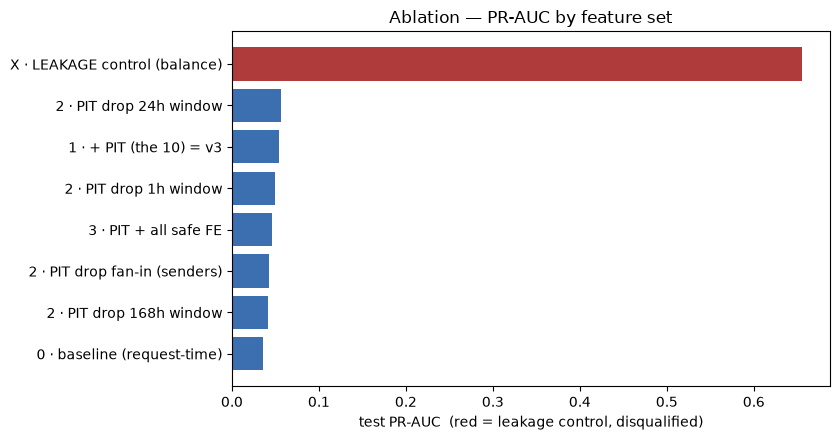

In [8]:
if results is not None:
    try:
        import matplotlib.pyplot as plt

        order = results.sort_values("pr_auc")
        colors = ["#b03b3b" if not d else "#3b6fb0" for d in order["deployable"]]
        fig, ax = plt.subplots(figsize=(8.5, 4.5))
        ax.barh(range(len(order)), order["pr_auc"], color=colors)
        ax.set_yticks(range(len(order)), labels=order["feature_set"])
        ax.set_xlabel("test PR-AUC  (red = leakage control, disqualified)")
        ax.set_title("Ablation — PR-AUC by feature set")
        fig.tight_layout()
        plt.show()
    except ImportError:
        print("matplotlib unavailable; table above is the result.")
else:
    print("Skipped: enable RUN_ABLATION above.")

### 📖 Cách đọc bảng/biểu đồ ablation
- **PR-AUC là thước đo chính** (cao hơn = tốt hơn); ROC-AUC để tham khảo.
- **Cột đỏ = arm LEAKAGE** — gần như chắc chắn đứng đầu, nhưng **bị loại** vì dùng dữ liệu sau giao dịch. Đây là 'trần gian lận', KHÔNG phải mục tiêu. Bài học: điểm cao chưa chắc hợp lệ.
- So **`baseline` → `+ PIT`**: PIT nâng được bao nhiêu = giá trị thật của 12 feature lịch sử.
- **Group-wise** (`drop 1h/24h/168h`, `drop recipient flags`): PR-AUC tụt nhiều nhất khi bỏ nhóm nào → nhóm đó tải tín hiệu mạnh nhất. Tụt gần như không đáng kể → nhóm đó gần như thừa.
- `+ all safe FE`: cả gói biến PIT-safe mới có thêm được gì so với PIT (chi tiết từng biến ở bảng additive bên dưới).
- **Nối với heatmap (notebook 07/08):** các feature tương quan cao (has_history vs count; window lồng nhau) thường bỏ đi mà PR-AUC ít đổi — đó là *feature-wise ablation* để làm model gọn.

### So sánh: biến MỚI nào thực sự thêm tín hiệu?
Thêm **từng** biến PIT-safe mới lên trên PIT12 rồi đo lại PR-AUC. Đây là câu trả lời trực tiếp cho 'biến nào phù hợp với dataset':
- `delta_vs_pit` **dương và lớn** = biến đó **đáng thêm**.
- `delta_vs_pit` **≈ 0 hoặc âm** = không giúp (thường vì trùng thông tin với 12 feature sẵn có — xem heatmap notebook 07).

In [9]:
# Which NEW PIT-safe feature actually adds signal? Add each one alone on top of PIT12.
additive = None
if frame is not None:
    base_pr = train_eval("pit_full", PIT12, frame)["pr_auc"]
    rows = []
    for feat in NEW_PIT_SAFE:
        pr = train_eval(f"+{feat}", [*PIT12, feat], frame)["pr_auc"]
        rows.append({"added_feature": feat, "pr_auc": pr, "delta_vs_pit": round(pr - base_pr, 6)})
    additive = (
        pd.DataFrame(rows).sort_values("delta_vs_pit", ascending=False).reset_index(drop=True)
    )
    print(f"pit_full PR-AUC = {base_pr:.6f}")
    display(additive)
else:
    print("Skipped: enable RUN_ABLATION above.")

pit_full PR-AUC = 0.053983


,added_feature,pr_auc,delta_vs_pit
0,senders_per_txn_24h,0.053983,0.000000
1,is_cold_recipient,0.053983,0.000000
2,amount_vs_avg_24h,0.053054,-0.000929
3,avg_prior_amount_24h,0.049132,-0.004851
4,burst_ratio_1h_24h,0.048903,-0.005080
5,count_acceleration,0.047528,-0.006455
6,avg_prior_amount_1h,0.047179,-0.006804
7,amount_vs_recent_avg_1h,0.045865,-0.008118


### 8 biến lịch sử PIT (v3) — mỗi biến đóng góp bao nhiêu?
Trước đây ta xây 10 feature PIT mà **chưa** kiểm định từng cái (nên hơi 'bựa'). Bù lại ở đây: mỗi feature lịch sử được thêm **đơn lẻ** lên baseline request-time, xem nó tự mình nâng PR-AUC bao nhiêu. `lift_vs_baseline` lớn = feature khỏe; ≈ 0 = gần vô dụng khi đứng một mình (vẫn có thể hữu ích khi kết hợp — đối chiếu bảng drop bên dưới).

In [10]:
# The 12 old PIT features get the same treatment: each history feature's standalone lift over
# the request-time baseline (the 3 static features ARE that baseline).
old_additive = None
if frame is not None:
    base_req = train_eval("baseline", STATIC, frame)["pr_auc"]
    rows = []
    for feat in HIST:
        pr = train_eval(f"+{feat}", [*STATIC, feat], frame)["pr_auc"]
        rows.append(
            {"pit_feature": feat, "pr_auc": pr, "lift_vs_baseline": round(pr - base_req, 6)}
        )
    old_additive = (
        pd.DataFrame(rows).sort_values("lift_vs_baseline", ascending=False).reset_index(drop=True)
    )
    print(f"baseline (request-time) PR-AUC = {base_req:.6f}")
    display(old_additive)
else:
    print("Skipped: enable RUN_ABLATION above.")

baseline (request-time) PR-AUC = 0.035548


,pit_feature,pr_auc,lift_vs_baseline
0,pit_prior_amount_1h,0.055858,0.020310
1,pit_steps_since_last_event,0.050486,0.014938
2,pit_prior_count_1h,0.045665,0.010117
3,pit_prior_count_24h,0.042973,0.007425
4,pit_distinct_senders_24h,0.042973,0.007425
5,pit_prior_amount_24h,0.042513,0.006965
6,pit_distinct_senders_168h,0.040152,0.004604
7,pit_prior_amount_168h,0.018702,-0.016846


### Leave-one-out trên toàn bộ 10 feature v3
Bỏ **từng** feature (cả 3 static lẫn 9 lịch sử) khỏi bộ đầy đủ, đo PR-AUC tụt bao nhiêu.

In [11]:
# Feature-wise ablation: drop each of the 12 features alone, measure the PR-AUC delta.
feature_wise = None
if frame is not None:
    base = train_eval("pit_full", PIT12, frame)["pr_auc"]
    rows = []
    for feat in PIT12:
        reduced = [f for f in PIT12 if f != feat]
        pr = train_eval(f"drop {feat}", reduced, frame)["pr_auc"]
        rows.append({"dropped_feature": feat, "pr_auc": pr, "delta_vs_full": round(pr - base, 6)})
    feature_wise = pd.DataFrame(rows).sort_values("delta_vs_full").reset_index(drop=True)
    print(f"pit_full PR-AUC = {base:.6f}")
    display(feature_wise)
else:
    print("Skipped: enable RUN_ABLATION above.")

pit_full PR-AUC = 0.053983


,dropped_feature,pr_auc,delta_vs_full
0,transaction_type_transfer,0.025198,-0.028785
1,current_amount,0.026301,-0.027682
2,pit_distinct_senders_168h,0.043200,-0.010783
3,pit_prior_amount_168h,0.044829,-0.009154
4,pit_prior_amount_1h,0.049164,-0.004819
5,pit_prior_count_1h,0.053103,-0.000880
6,pit_distinct_senders_24h,0.053983,0.000000
7,pit_prior_count_24h,0.054095,0.000112
8,pit_prior_amount_24h,0.054174,0.000191
9,pit_steps_since_last_event,0.057925,0.003942


### Bước 2 · Chốt bộ feature sạch từ bằng chứng ablation (LOO trên VAL)

📖 Áp đúng luật của quy trình: **Δ = PR-AUC(đầy đủ) − PR-AUC(bỏ f)** trên **VAL**. Feature nào **Δ ≤ 0** (bỏ ra mà Val không giảm, thậm chí tăng) → **loại**. Bộ còn lại là `SELECTED_FEATURES`, được **lưu ra JSON** để nb10 (CV) / nb11 (Optuna) / nb12 (Test) **tự nạp** — đảm bảo Bước 3–4 dùng đúng bộ feature đã chốt ở Bước 2, không phải một list cứng.

> Ứng viên = 10 field contract v3 (`PIT12`). Luôn giữ 2 feature request-time nền. LOO một-split nhạy với collinearity, nên nếu luật loại quá tay thì giữ nguyên PIT12 và ghi rõ (đối chiếu heatmap nb07/08).

In [12]:
# Bước 2: chốt bộ feature sạch (LOO tren VAL, luat Δ<=0). feature_wise.delta_vs_full = PR-AUC(bo f) - PR-AUC(full) = -Δ.
SELECTED_FEATURES = None
if feature_wise is not None:
    from pit_fintech.models.notebook_lab import STATIC_FEATURES, save_selected_features

    # Δ<=0  <=>  delta_vs_full >= 0  => bo f khong hai/tot len => LOAI.
    dropped = set(feature_wise.loc[feature_wise["delta_vs_full"] >= 0, "dropped_feature"])
    SELECTED_FEATURES = [f for f in PIT12 if f not in dropped or f in STATIC_FEATURES]
    if len(SELECTED_FEATURES) < 3:
        print("[canh bao] Luat Δ<=0 loai qua nhieu (collinearity) -> giu nguyen PIT12.")
        SELECTED_FEATURES = list(PIT12)
    saved_path = save_selected_features(SELECTED_FEATURES, source="nb09-ablation-loo-val")
    print(f"Loai (Δ<=0 tren Val): {sorted(dropped)}")
    print(f"SELECTED_FEATURES ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")
    print(f"Da luu -> {saved_path}  (nb10/11/12 tu nap qua load_selected_features()).")
else:
    print("Skipped: enable RUN_ABLATION above.")

Loai (Δ<=0 tren Val): ['pit_distinct_senders_24h', 'pit_prior_amount_24h', 'pit_prior_count_24h', 'pit_steps_since_last_event']
SELECTED_FEATURES (6): ['current_amount', 'transaction_type_transfer', 'pit_prior_count_1h', 'pit_prior_amount_1h', 'pit_prior_amount_168h', 'pit_distinct_senders_168h']
Da luu -> C:\workspace\pit-fintech\artifacts\notebook_lab\selected_features.json  (nb10/11/12 tu nap qua load_selected_features()).


### 📖 Cách đọc feature-wise
`delta_vs_full` = PR-AUC khi bỏ 1 feature trừ đi PR-AUC đầy đủ. **Âm nhiều** = bỏ feature đó làm model tệ đi rõ → feature quan trọng, **giữ**. **Gần 0 hoặc dương** = bỏ đi không hại (thậm chí đỡ nhiễu) → **ứng viên loại bỏ** để model gọn hơn (nhất là các feature đã thấy trùng thông tin trên heatmap). Lưu ý: bỏ *thật* một stored feature là contract v3 + ADR + backfill — ở đây chỉ mới *đo bằng chứng*, chưa bỏ.

## Kết luận & bước tiếp
- **Tín hiệu thật vs leakage:** arm leakage thắng metric nhưng bị loại — đó là lý do dự án cấm 4 cột số dư. Model deployable chỉ dùng feature PIT-safe.
- **Đóng góp theo nhóm:** group-wise cho biết cửa sổ nào (1h/24h/168h) và fan-in tải tín hiệu mạnh nhất.
- **Gọn hoá:** feature-wise + heatmap (nb07/08) chỉ ra feature trùng lặp có thể đề xuất bỏ (cần contract mới + ADR + backfill).
- Feature v3 (`pit_distinct_senders_*`, `pit_steps_since_last_event`) là kết quả của chính vòng ablation cold-start này; các candidate tiếp theo chỉ mở khi ablation cho thấy còn buffer.

Kết quả ở đây là **exploratory** (feature tính từ Silver, không đọc Gold); bản ablation chính thức (manifest, gate) chạy qua `training/` theo plan.

## Ghi bằng chứng feature-selection lên MLflow (`stage=fe`)

📖 **Cell dưới** log bảng ablation, bảng additive (biến mới) và leave-one-out lên experiment `paysim-notebook-modeling` (server host ở `settings.mlflow_tracking_uri`). Đây là *nhật ký lab* — tag `manifest_backed=false` để không lẫn với bằng chứng promotable của `training/`.

In [13]:
# Log the ablation / selection evidence to MLflow (exploratory lab; stage=fe).
LOG_TO_MLFLOW = True
if LOG_TO_MLFLOW and results is not None:
    from pit_fintech.models.notebook_lab import (
        LAB_EXPERIMENT,
        MLFLOW_LAB_TAGS,
        configure_lab_mlflow,
    )

    mlflow = configure_lab_mlflow()
    if mlflow is None:
        print("mlflow not in kernel -> skipped (run in the training env group).")
    else:
        with mlflow.start_run(run_name="nb09-feature-engineering-selection"):
            mlflow.set_tags(
                {**MLFLOW_LAB_TAGS, "stage": "fe", "notebook": "09_feature_engineering_selection"}
            )
            mlflow.log_params(
                {"seed": SEED, "n_pit_features": len(PIT12), "n_new_pit_safe": len(NEW_PIT_SAFE)}
            )
            if SELECTED_FEATURES:
                mlflow.log_param("n_selected_features", len(SELECTED_FEATURES))
                mlflow.log_param("selected_features", ",".join(SELECTED_FEATURES))
            deployable = results[results["deployable"]]
            mlflow.log_metric("best_deployable_pr_auc", float(deployable["pr_auc"].max()))
            leak = results[~results["deployable"]]
            if len(leak):
                mlflow.log_metric("leakage_control_pr_auc", float(leak["pr_auc"].max()))
            for name, table in [
                ("ablation_results", results),
                ("additive_new_features", additive),
                ("feature_wise_loo", feature_wise),
            ]:
                if table is not None:
                    csv_path = f"{name}.csv"
                    table.to_csv(csv_path, index=False)
                    mlflow.log_artifact(csv_path)
        print(f"Logged -> nb09 @ {mlflow.get_tracking_uri()} (experiment '{LAB_EXPERIMENT}')")
else:
    print("MLflow off or ablation not run.")

🏃 View run nb09-feature-engineering-selection at: http://100.116.36.6:5000/#/experiments/1/runs/a08cff60ce4e471abb9653dabe7d0bb7
🧪 View experiment at: http://100.116.36.6:5000/#/experiments/1
Logged -> nb09 @ http://100.116.36.6:5000 (experiment 'paysim-notebook-modeling')


In [14]:
from pit_fintech.config import get_settings

print(get_settings().mlflow_tracking_uri)

http://100.116.36.6:5000
